## **HW5: Decision Trees**
### **TODO: Martin Jesus Colmenero Jr**

**Attention:** This is an individual assignment.


### **Introduction**
As a Data Scientist at an AI company, you are tasked with analyzing employee data to understand the key factors that influence retention. Your company’s Human Resources (HR) department has collected data from approximately 1,400 employees over several years, capturing details about their work environment, job roles, salaries, work-life balance, and overall satisfaction.

One of the biggest challenges companies face is retaining top talent. Employee attrition (when employees leave the company) can be costly, both in terms of productivity and recruitment expenses. By leveraging machine learning techniques, your goal is to identify patterns in employee data that predict whether an employee is likely to leave or stay.

### **Objective**

In this assignment, you will apply a Decision Tree Classifier to analyze the HR dataset and predict whether a given employee will stay or leave the company. You will explore:
- Which factors are most important in predicting employee attrition.
- How decision trees can be used to classify employees based on their likelihood of staying.
- How HR teams can use this model to make data-driven decisions to improve retention strategies.

By the end of this assignment, you will have built a predictive model that helps HR professionals understand what drives employee retention and how to reduce attrition in the organization.

## **Instructions**

To perform predictive and descriptive analytics, you will use the [Decision Tree Classifier](https://scikit-learn.org/stable/modules/tree.html#classification) class in the `scikit-learn`.

  
For this assignment, the stopping condition will be the depth of the tree. The impurity measure can be either `Entropy` or `Gini`.

To test our tree built from the Decision Tree Classifier class, we will use a dataset named Employee Attrition (synthetic data, no real employees but still helpful). The dataset file is provided to you. However, it is highly recommended to review the Kaggle link below to learn more about the  dataset and its features.

   - https://www.kaggle.com/datasets/patelprashant/employee-attrition/data

There are 35 features in these CSV file that we can use to describe and predict the class label of the employee 'Attrition', which is 'Yes' or 'No'. Meaning if the employee has stayed in the company or left.

In [70]:
# import the libraries
!pip install graphviz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import log2
from sklearn import tree # you'll probably need to install this
import graphviz # you'll probably need to install this
import seaborn as sns
sns.set_style('darkgrid')

## **Load Data**

In this step, we load the dataset and view the first few rows to ensure proper loading.
We'll use pandas to read the CSV file and display the first few rows of the dataset.

In [71]:
# Write your code here
df = pd.read_csv('employee_attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# **Q1: Explore the distribution of the target column "Attrition" and the rest of the features.**

 ### **Q 1.1 Use `value_counts` to get the statistics of `Attrition` label.**

In [72]:
# Write your code here
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


### **Q 1.2**

An imbalanced dataset occurs when there is an uneven distribution of classes, meaning one class appears significantly more frequently than the other.

* Is this the case for this datasets?
* What challenges could arise from class imbalance?
* Give one or two ideas on how would you handle this (don't implement them).

### **WRITE YOUR ANSWER HERE:**
- In this case, this is an inbalanced dataset since we have significantly more instances of employees not leaving [Attrition | No] than employee leaving [Attrition | Yes]
- Our model will make biased predictions mostly towards the majority class, the model won't be able to recognize patterns regarding the minority class, the model will misclassify the minority class, and our evaluation of the model will be misleading, specifically the accuracy.
- In this case, remove the minorty class [Attrition | Yes] and use a logit model to predict the probability of an employee staying in the company. Second, reduce the sample data for the majority class [Attrition | No]


### **Q 1.3**

Select two features that you find interesting and visualize their distributions. Create appropriate plots to explore their patterns and analyze any insights from their distribution.

* Use Seaborn's histplot to visualize the distribution
* Set `kde = True` paarmeter in the histogram to include a smooth density estimation curve

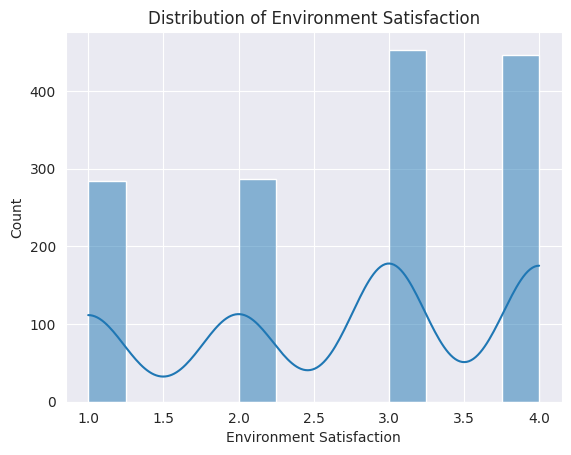

In [73]:
# Write your code here for plot 1 here
sns.histplot(data=df['EnvironmentSatisfaction'], kde=True)
plt.xlabel('Environment Satisfaction')
plt.ylabel('Count')
plt.title('Distribution of Environment Satisfaction')
plt.show()

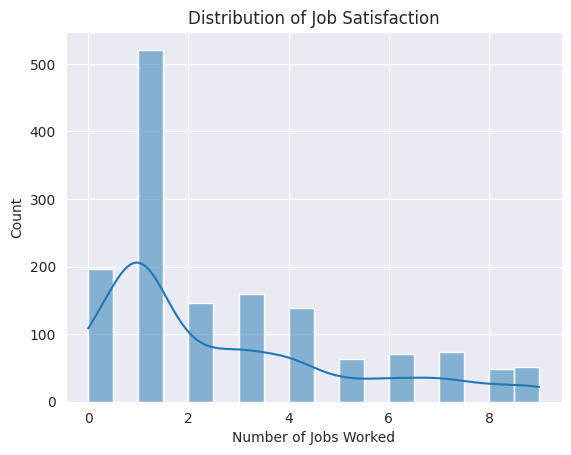

In [74]:
# Write your code here plot 2 here
sns.histplot(data=df['NumCompaniesWorked'], kde=True)
plt.xlabel('Number of Jobs Worked')
plt.ylabel('Count')
plt.title('Distribution of Job Satisfaction')
plt.show()

# **Q2. Feature Engineering**

## **Q2.0 Print shape of the dataframe:**

In [75]:
# Write your code here
print(df.shape)

(1470, 35)


## **Q2.1 Using the training dataset:**

* Extract the feature columns and save them in a dataframe named `df_features`.
* Extract the target column and save it in a dataframe named `df_target`.
* Print the first few rows of the new dataframes

In [76]:
# Write your code here
df_features = df.drop('Attrition', axis=1)
df_features.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,...,1,80,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,...,4,80,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,...,2,80,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,...,3,80,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,...,4,80,1,6,3,3,2,2,2,2


In [77]:
# Write your code here
df_target = df['Attrition']
df_target.head()

,Attrition
0,Yes
1,No
2,Yes
3,No
4,No


In [78]:
# Write your code here
print(f'df_features: {df_features.shape}')
print(f'df_target: {df_target.shape}')


df_features: (1470, 34)
df_target: (1470,)


## **Q2.2 Extract the categorical data from the features dataframe, store them into a new dataframe named `categorical_variables` and print the results**


In [79]:
# Write your code here
# Using list comprehension and select_dtypes to find categorical columns
categorical_data = [col for col in df_features.columns if df_features[col].dtype == 'object']
categorical_variables = df_features[categorical_data]
categorical_variables.head()

,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No


## **Q2.3 Split into Training and Testing sets**
* Apply `.squeeze()` on df_target to ensure it has correct shape.
* Split the data into training and testing sets
* Print the shape of `X_train`, `X_test`, `y_train`, and `y_test` to verify split

In [80]:
from sklearn.model_selection import train_test_split
# Write your code here
y = df_target.squeeze()
X = df_features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, train_size = 0.8)

In [81]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1176, 34), (294, 34), (1176,), (294,))

# **Q3. Build a decision tree classifier.**

* Using [scikit-learn](https://scikit-learn.org/stable/modules/tree.html#tree) create a multi class classifer for the data set using the Gini impurity measure and a max depth of 3.

* Note that `scikit-learn`'s algorithm doesn't handle categorical data, so you will need to encode categorical data using one hot encoding.
For this question, you will use `X_train` and `y_train` that you created above.


In [82]:
# Write your code here
X_train = pd.get_dummies(X_train)

clf = tree.DecisionTreeClassifier(criterion='gini', max_depth=3)
clf = clf.fit(X_train, y_train)

# **Q4. Visualize the Tree model you have implemented above.**

* Generate and display the decision tree using Graphviz to visualize its structure.
* Analyze the tree visualization and write the sequence of decision it follows to reach the leaftmost leaf node.

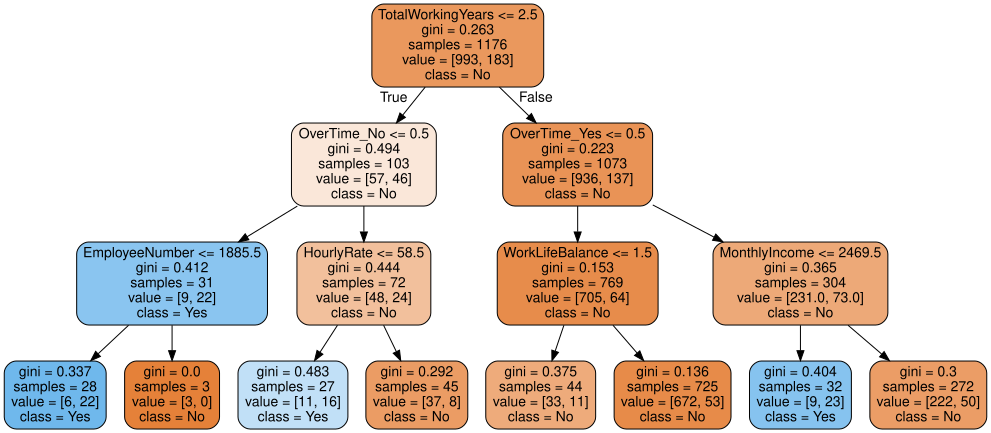

In [83]:
# Write your code here
graph_data = tree.export_graphviz(clf, out_file=None,
                                  feature_names=list(X_train.columns),
                                  class_names=list(set(y_train)),
                                  filled=True, rounded=True)
graph = graphviz.Source(graph_data)
graph

## **WRITE YOUR ANSWER HERE:**
- TotalWorkingYears <= 2.5
- OverTime_No <= 0.5
- EmployeeNumber <= 1885.5

# **Q5. Making predictions**

## **Q5.1 Preprocess the test dataset as you did for the training set**

* One hot encode the categorical data of `X_test`, -- use pandas `get_dummies()` : https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
* Print the first few rows of the new dataframe

In [84]:
# Write your code here
X_test = pd.get_dummies(X_test)
X_test.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
1052,30,990,7,3,1,1482,3,64,3,1,...,False,True,False,False,True,False,False,True,True,False
1253,33,1283,2,3,1,1756,4,62,3,2,...,False,False,True,False,False,False,True,True,True,False
360,57,593,1,4,1,482,4,88,3,2,...,False,False,False,False,False,True,False,True,True,False
201,49,1002,18,4,1,275,4,92,3,2,...,False,False,False,False,True,False,False,True,False,True
1007,29,337,14,1,1,1421,3,84,3,3,...,False,False,False,False,False,False,True,True,False,True


## **Q5.2 Extract one sample from the testing data, make a prediction, and visualize the prediction path**

In [85]:
# Now, let's extract a random data instance from df_test
import random

random_instance_index = random.randint(0, len(X_test) - 1)
random_instance = X_test.iloc[random_instance_index, :]


# Visualize the prediction node path
node_indicator = clf.decision_path(random_instance.values.reshape(1,-1))

# Get the indices of the nodes visited along the decision path
node_indices = node_indicator.indices

# Extract the node names and conditions for the decision path
decision_path_info = []

for node_index in node_indices:
    # Get the feature index used at this node
    feature_index = clf.tree_.feature[node_index]

    if feature_index != -2:  # Check if it's not a leaf node (-2 represents leaf nodes)
        # Get the feature name and threshold (condition) used at this node
        feature_name = X_test.columns[feature_index]
        threshold = clf.tree_.threshold[node_index]
        condition = f'{feature_name} <= {threshold:.2f}'
        decision_path_info.append((node_index, feature_name, condition))


# Print the extracted decision path information
for node_index, feature_name, condition in decision_path_info:
    print(f"Node {node_index}: {condition}")

Node 0: TotalWorkingYears <= 2.50
Node 8: OverTime_Yes <= 0.50
Node 12: MonthlyIncome <= 2469.50


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## **Q5.3 Get the predicted result for the test set**

* assess the accuracy of your decision tree model. Use `accuracy_score` from `sklearn.metrics` to compare the model's predictions against the actual target values in the test dataset.


In [89]:
# Write your code here
from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.82


## **Q5.4 Get the confusion matrix and visualize it**


* generate and visualize a confusion matrix for your decision tree model using `confusion_matrix` from `sklearn.metrics` and seaborn for heatmap visualization.

In [90]:
# Write your code here
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[228,  12],
       [ 41,  13]])

## **5.4 Interpret results**

After creating the confusion matrix, analyze the results:

* **A** What do the values in each cell of the matrix represent?
* **B** How do false positives and false negatives impact the interpretation of the model's performance?
* **C** Why might a confusion matrix provide deeper insights than accuracy alone?
* **D** Based on the confusion matrix, what potential improvements could be made to the model?

## **WRITE YOUR ANSWER HERE**
- **A**: Top left cell represents the number of times the model made correctly predictions the True class. Top right cell represents the number of times the model incorrectly predicted the class when it was actually False. The bottom left cell represents the number of instances the model incorrectly predicted the class when it was actually True. The bottom right cell represents the number of instances the model was able to correcly predict the False class.

- **B**: False Positives and False Negatives both cause the model to missclassify data and provide incorrect or misleading results.

- **C**: Since we can see the model's predictions compared to the acutal outcomes, we can see the error rate of the model

- **D**: Based on the confusion matrix, we have a relatively large number of False Negative cases so the model is failing to predict when an employee is actually leaving. We could adjust the thresholds of features in the decision tree to help capture cases when employee do leave the company. We could also increase the depth of the tree to include more features.

## **Q6. Provide a Comprehensive Analysis of Your Findings (15 pts)**

**IMPORTANT**
For eah of the question below, your responses should be concise but grounded in data. Avoid vague or general statements—base your analysis on the dataset and the results from your code. Use specific language and critical thinking to support your conclusions to receive full points for this question.


* **A.** Decision Tree Insights: Explain your observations after modeling and visualizing the decision tree. What key patterns or takeaways emerge?
* **B.** Feature Engineering Impact: Describe the feature engineering steps applied, the rationale behind them, and their effect on model performance.
* **C.** Model Suitability: Assess whether a decision tree is an appropriate method for this problem. Justify your reasoning based on efficiency, interpretability, and predictive power.
* **D.** Business Implications: How can insights from employee attrition analysis inform business decisions? Discuss how data science can influence company operations and policies when leadership acts on these findings.

## **WRITE YOUR ANSWER HERE:**
- **A**: When creating the Tree, the max_depth of the tree is only 3 so the tree may be leaving out important features to make predictions. Currently, the visuallized tree shows that TotalWorkingYears is the strongest feature for predicting Attrition, however I predict that EnvironmentSatisfaction is a better predictor.

- **B**: We extracted and analyzed all categorical features in the dataframe. Since Decision Trees can't handle categorical data we neeeded to hot encode all the categorical features in the dataframe so the model could use that data.

- **C**: Since our dataset is unabalnced, where the majority class is employees not leaving the company, the decision tree is more likely to predict patterns for employees that stay in the company, rather than make recognizing patterns for employees leaving and staying. Based on the accuracy score (0.82) and the results of the confusion matrix, the decision is making biased prediction due the imlanced dataset

- **D**: Business decisions can be influced by the factors that most influence employee attrition. In this case, if TotalWorkingYears is the most important factor that predicts employee attrition, then companies may want to offer raises or promotions for longer standing employees to incentivice employee retention. Data science can influence company operations by using predictive models to give leadership confidence in future policies that could benefit the company.